# Estadistica

## Estadistica Descriptiva

In [1]:
import numpy as np
import statistics as stats
import matplotlib.pyplot as plt

In [2]:
data = [10, 15, 15, 18, 20, 25, 30, 30, 30, 35, 40]

In [6]:
mean = stats.mean(data)
print(f"Media: {mean}")

Media: 24.363636363636363


In [7]:
median = stats.median(data)
print(f"Mediana: {median}")

Mediana: 25


In [8]:
try:
    mode = stats.mode(data)
    print(f"Moda: {mode}")
except stats.StatisticsError as e:
    print(f"Error al calcular la moda: {e}")

Moda: 30


In [10]:
range_value = max(data) - min(data)
print(f"Rango: {range_value}")

Rango: 30


In [12]:
def calcular_simetria(data):
    mean = stats.mean(data)
    median = stats.median(data)
    if mean > median:
        return "Asimétrica a la derecha"
    elif mean < median:
        return "Asimétrica a la izquierda"
    else:
        return "Simétrica"

In [13]:
print(calcular_simetria(data))

Asimétrica a la izquierda


In [14]:
varianza = stats.variance(data)
print(f"Varianza: {varianza}")

Varianza: 89.45454545454545


In [ ]:
desviacion_estandar = stats.stdev(data)
print(f"Desviación estándar: {desviacion_estandar}")

Desviación estándar: 9.458041311738148


## Medidas de asociacion

In [4]:
from scipy import stats
import numpy as np



In [ ]:
data_x = [10, 15, 20, 25, 30]
data_y = [12, 18, 25, 35, 40]

# la covariancia indica direccion de la relacion entre las variables, si es positiva (tienden a aumentar juntas), negativa o nula
covarianza_matriz = np.cov(data_x, data_y)
covarianza = covarianza_matriz[0][1]    
print(f"Covarianza: {covarianza}")
print("las variables aumentan juntas")


Covarianza: 91.25


In [6]:
#correlacion de pearson, fuerza y direccion de la realcion lineal entre dos variables, va de -1 a 1, si es positiva (aumentan juntas), negativa o nula
correlacion, _ = stats.pearsonr(data_x, data_y)
print(f"Correlación de Pearson: {correlacion}")


Correlación de Pearson: 0.9952489367473116


In [7]:
# correlacion de spearman, fuerza y direccion de la relacion monotona entre dos variables, va de -1 a 1, si es positiva (aumentan juntas), negativa o nula
correlacion_spearman, _ = stats.spearmanr(data_x, data_y)
print(f"Correlación de Spearman: {correlacion_spearman}")

Correlación de Spearman: 0.9999999999999999


In [8]:
# correlacion de kendall, concodancia entre dos variables, va de -1 a 1, si es positiva (aumentan juntas), negativa o nula
correlacion_kendall, _ = stats.kendalltau(data_x, data_y)
print(f"Correlación de Kendall: {correlacion_kendall}")


Correlación de Kendall: 0.9999999999999999


## Medidas de Posicion

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = [10, 15, 15, 18, 20, 25, 30, 30, 30, 35, 40]
#calculo de cuartiles
q1 = np.percentile(data, 25)
q2 = np.percentile(data, 50) # es la mediana
q3 = np.percentile(data, 75)
print(f"Q1: {q1}, Q2: {q2}, Q3: {q3}")

Q1: 16.5, Q2: 25.0, Q3: 30.0


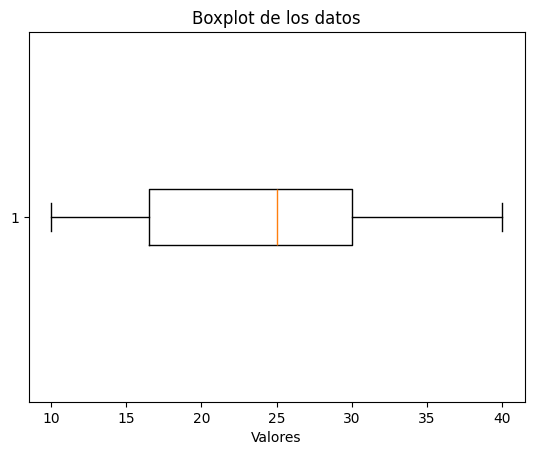

In [11]:
# creo el boxplot
plt.boxplot(data, vert=False)
plt.title("Boxplot de los datos")
plt.xlabel("Valores")
plt.show()

## Estadistica Inferencial

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns

In [26]:
data_klout = pd.read_csv('klout-scores.csv', header=None, names=['scores'])
print(data_klout.shape)

(1048, 1)


In [28]:
# saco muestra de tamaño 25 de esos datos
sample = data_klout.sample(n=25,replace=False, random_state=1234, axis=0)
print(sample.shape)


(25, 1)


In [30]:
# repeti lo hecho con un generador de numeros de distribucion uniforme para generar los inidces de las filas a seleccionar
random_generator = np.random.default_rng(seed=1234)
index_sample = random_generator.choice(data_klout.index, size=25, replace=False)
sample2 = data_klout.loc[index_sample]
print(sample2.shape)

(25, 1)


In [33]:
# Calculo valores criticos que usariamos para intervalos de confiancia para el valor medio de una muestra de 25
from scipy import stats

n=20 
alpha = 0.05
critical_value_normal = stats.norm.ppf(alpha/2)
print(f"Valor crítico para distribución normal: {critical_value_normal}")

Valor crítico para distribución normal: -1.9599639845400545


In [35]:
df = n-1
critical_value_t = stats.t.ppf(alpha/2, df) # t de student
print(f"Valor crítico para distribución t de Student: {critical_value_t}")

Valor crítico para distribución t de Student: -2.09302405440831


## Pruebas de Hipotesis

### Ejemplo de test de hipotesis

In [38]:
import scipy.stats as stats
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [39]:
# calcular para media poblacional que afierma que los chicos de 3 a 5 años que miran tv es de 22 horas
# datos de muestra
media_muestral = 25
media_h0 = 22
sd = 6
n = 64

In [42]:
# construyo el estadistico de prueba
Z = (media_muestral - media_h0) / (sd / math.sqrt(n))
print(f"Estadístico de prueba Z: {Z}")

alpha = 0.05
print(f"nivel de significancia: {alpha}")

Estadístico de prueba Z: 4.0
nivel de significancia: 0.05


In [43]:
# ahora calculo la probabilidad de obtener un valor de 4 o mas, para un Z dado que zeta tiene distribucion normal de 1
1-stats.norm.cdf(Z)

np.float64(3.167124183311998e-05)

In [ ]:
# esto muestra que si H0 es verdadera, el poco probable de obtener un valor de 4 o mas es de 0.00003, 
# por lo que se rechaza H0 y se concluye que la media poblacional es mayor a 22 horas


In [44]:
alpha = 1-0.05
Z_critico = stats.norm.ppf(alpha)
print(f"Valor crítico Z para un nivel de significancia del 5%: {Z_critico}")

Valor crítico Z para un nivel de significancia del 5%: 1.6448536269514722


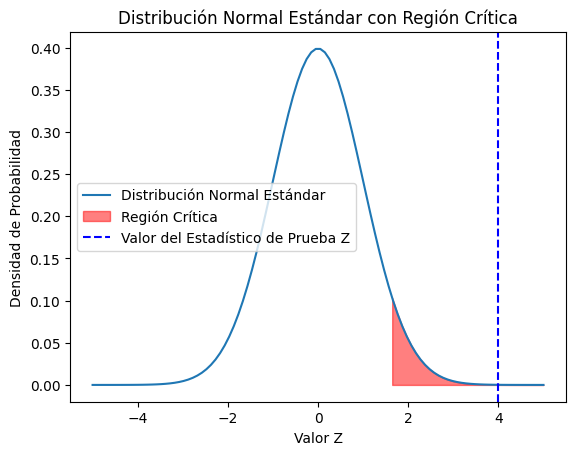

In [51]:
critical_value = Z_critico
samples = 100
x_plot = np.linspace(-5, 5, samples)
plot = stats.norm.pdf(x_plot, 0, 1)
plt.plot(x_plot, plot, label='Distribución Normal Estándar')

# grafico region critica

xcritical = np.linspace(critical_value, 5, samples)
ycritical = stats.norm.pdf(xcritical, 0, 1)
#coloreo region de rechazo
plt.fill_between(xcritical, ycritical, color='red', alpha=0.5, label='Región Crítica')
plt.axvline(x=Z, color='blue', linestyle='--', label='Valor del Estadístico de Prueba Z')
plt.title('Distribución Normal Estándar con Región Crítica')
plt.xlabel('Valor Z')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.show()

## Series Temporales


In [60]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.tsa.api as smt


In [63]:
from scipy import stats
from statistics import mode

In [65]:
import warnings
warnings.filterwarnings("ignore")

In [67]:
# defino dataframe
df = pd.read_excel('Supertienda.xls')

In [79]:
mobilario = df.loc[df['Categoria'] == 'Mobiliario']

In [80]:
mobiliario_gb = mobilario.groupby('Fecha_pedido')['Ventas'].sum().reset_index()
mobiliario_gb = mobiliario_gb.set_index('Fecha_pedido')
y= mobiliario_gb['Ventas'].resample('MS').mean()


<Figure size 1600x1000 with 0 Axes>

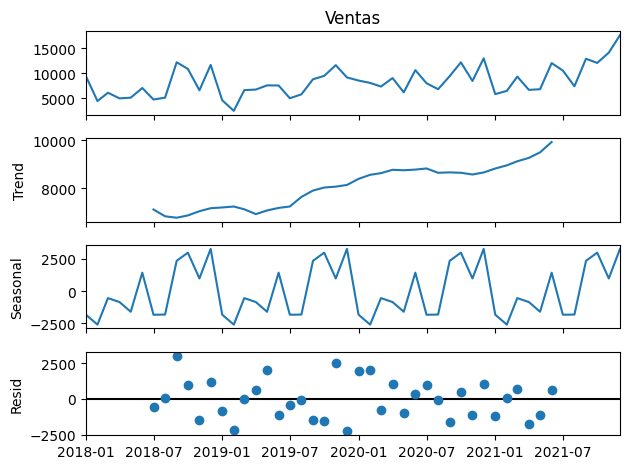

In [81]:
plt.figure(figsize=(16, 10))
decomposition = sm.tsa.seasonal_decompose(y, model='additive')
decomposition.plot()
plt.show()